# 1 Creating and Manipulating Arrays

First import numpy and matplotlib

In [8]:
import numpy as np
from matplotlib import pyplot as plt

## 1.1. Create two 2D arrays representing coordinates x, y on the cartesian plan
Both should cover the range (-2, 2) and have 100 points in each direction

In [9]:
x = np.linspace(-2, 2, 100)
y = np.linspace(-2,2, 100)

In [10]:
x

array([-2.        , -1.95959596, -1.91919192, -1.87878788, -1.83838384,
       -1.7979798 , -1.75757576, -1.71717172, -1.67676768, -1.63636364,
       -1.5959596 , -1.55555556, -1.51515152, -1.47474747, -1.43434343,
       -1.39393939, -1.35353535, -1.31313131, -1.27272727, -1.23232323,
       -1.19191919, -1.15151515, -1.11111111, -1.07070707, -1.03030303,
       -0.98989899, -0.94949495, -0.90909091, -0.86868687, -0.82828283,
       -0.78787879, -0.74747475, -0.70707071, -0.66666667, -0.62626263,
       -0.58585859, -0.54545455, -0.50505051, -0.46464646, -0.42424242,
       -0.38383838, -0.34343434, -0.3030303 , -0.26262626, -0.22222222,
       -0.18181818, -0.14141414, -0.1010101 , -0.06060606, -0.02020202,
        0.02020202,  0.06060606,  0.1010101 ,  0.14141414,  0.18181818,
        0.22222222,  0.26262626,  0.3030303 ,  0.34343434,  0.38383838,
        0.42424242,  0.46464646,  0.50505051,  0.54545455,  0.58585859,
        0.62626263,  0.66666667,  0.70707071,  0.74747475,  0.78

In [11]:
y

array([-2.        , -1.95959596, -1.91919192, -1.87878788, -1.83838384,
       -1.7979798 , -1.75757576, -1.71717172, -1.67676768, -1.63636364,
       -1.5959596 , -1.55555556, -1.51515152, -1.47474747, -1.43434343,
       -1.39393939, -1.35353535, -1.31313131, -1.27272727, -1.23232323,
       -1.19191919, -1.15151515, -1.11111111, -1.07070707, -1.03030303,
       -0.98989899, -0.94949495, -0.90909091, -0.86868687, -0.82828283,
       -0.78787879, -0.74747475, -0.70707071, -0.66666667, -0.62626263,
       -0.58585859, -0.54545455, -0.50505051, -0.46464646, -0.42424242,
       -0.38383838, -0.34343434, -0.3030303 , -0.26262626, -0.22222222,
       -0.18181818, -0.14141414, -0.1010101 , -0.06060606, -0.02020202,
        0.02020202,  0.06060606,  0.1010101 ,  0.14141414,  0.18181818,
        0.22222222,  0.26262626,  0.3030303 ,  0.34343434,  0.38383838,
        0.42424242,  0.46464646,  0.50505051,  0.54545455,  0.58585859,
        0.62626263,  0.66666667,  0.70707071,  0.74747475,  0.78

In [12]:
xx,yy = np.meshgrid(x,y)

In [13]:
print(xx.shape)

(100, 100)


In [14]:
print(yy.shape)

(100, 100)


## 1.2. Visualize each 2D array using pcolormesh

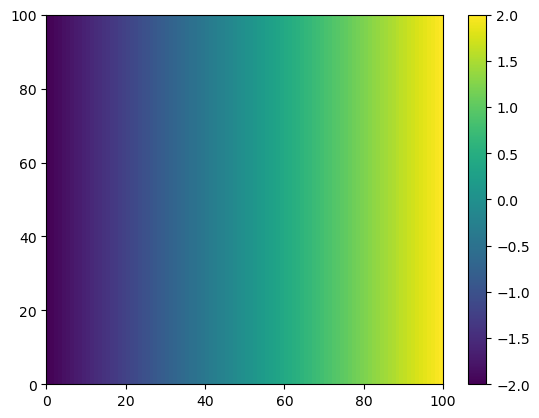

In [15]:
plt.pcolormesh(xx)
plt.colorbar()

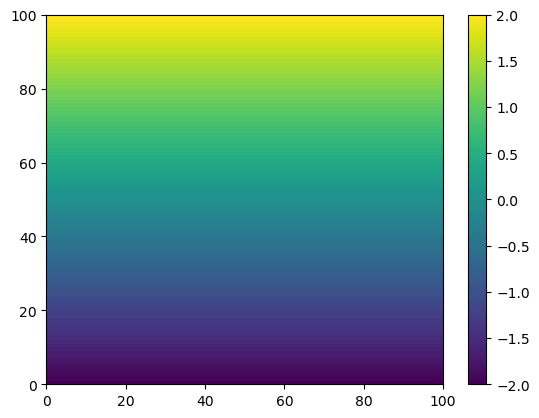

In [16]:
plt.pcolormesh(yy)
plt.colorbar()

## 1.3 From your cartesian coordinates, create polar coordinates *radius* and *theta*

Refer to the wikipedia page for the conversion formula. You will need to use numpy’s arctan2 function. Read its documentation.

In [17]:
radius = np.sqrt(xx**2 + yy**2)
theta = np.arctan2(yy, xx)

## 1.4. Visualize *radius* and *theta* on the 2D x/y plane using pcolormesh


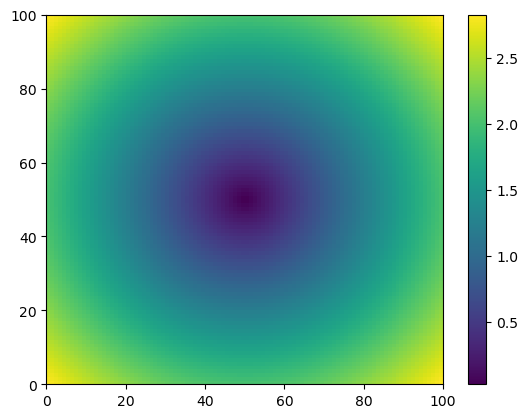

In [18]:
plt.pcolormesh(radius)
plt.colorbar()

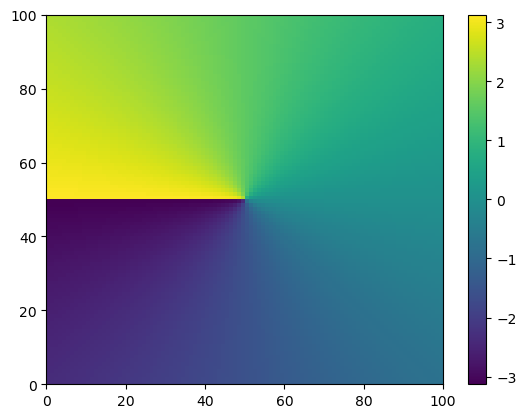

In [19]:
plt.pcolormesh(theta)
plt.colorbar()

## 1.5 Calculate the quantity f = (cos(4radius))^2 + (sin(4theta))^2
 And plot it on the x/y$ plane

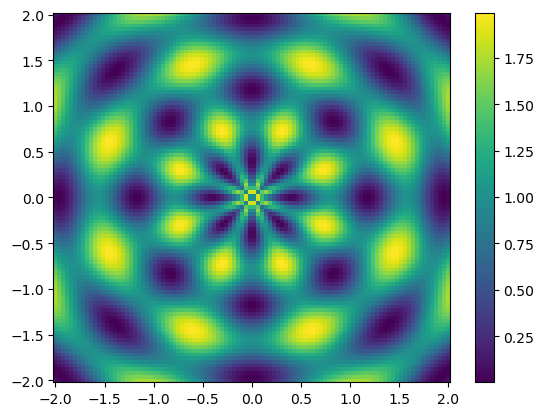

In [108]:
f = (np.cos(4*radius))**2 + (np.sin(4*theta))**2
plt.pcolormesh(x,y,f)
plt.colorbar()

# Part 2: Analyze ARGO Data

In this problem, we use real data from ocean profiling floats. ARGO floats are autonomous robotic instruments that collect Temperature, Salinity, and Pressure data from the ocean. ARGO floats collect one “profile” (a set of measurements at different depths or “levels”).

Each profile has a single latitude, longitude, and date associated with it, in addition to many different levels.

Let’s start by using pooch to download the data files we need for this exercise. The following code will give you a list of .npy files that you can open in the next step.

In [21]:
import pooch
url = "https://www.ldeo.columbia.edu/~danielmw/float_data.zip"
files = pooch.retrieve(url, processor=pooch.Unzip(), known_hash="2a703c720302c682f1662181d329c9f22f9f10e1539dc2d6082160a469165009")
files

['/home/ktw2128/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/date.npy',
 '/home/ktw2128/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/T.npy',
 '/home/ktw2128/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/S.npy',
 '/home/ktw2128/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/P.npy',
 '/home/ktw2128/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/levels.npy',
 '/home/ktw2128/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/lon.npy',
 '/home/ktw2128/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/lat.npy']

## 2.1 Load each data file as a numpy array.

You can use whatever names you want for your arrays, but I recommend

T: temperature

S: salinity

P: pressure

date: date

lat: latitude

lon: longitude

level: depth level

Note: you have to actually look at the file name (the items in files) to know which files corresponds to which variable.

In [22]:
import numpy as np

In [23]:
files

['/home/ktw2128/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/date.npy',
 '/home/ktw2128/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/T.npy',
 '/home/ktw2128/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/S.npy',
 '/home/ktw2128/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/P.npy',
 '/home/ktw2128/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/levels.npy',
 '/home/ktw2128/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/lon.npy',
 '/home/ktw2128/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/lat.npy']

In [24]:
np.load(files[6])

array([47.187, 46.716, 46.45 , 46.23 , 45.459, 44.833, 44.452, 44.839,
       44.956, 44.676, 44.13 , 43.644, 43.067, 42.662, 42.513, 42.454,
       42.396, 42.256, 42.089, 41.944, 41.712, 41.571, 41.596, 41.581,
       41.351, 41.032, 40.912, 40.792, 40.495, 40.383, 40.478, 40.672,
       41.032, 40.864, 40.651, 40.425, 40.228, 40.197, 40.483, 40.311,
       40.457, 40.463, 40.164, 40.047, 39.963, 40.122, 40.57 , 40.476,
       40.527, 40.589, 40.749, 40.993, 41.162, 41.237, 41.448, 41.65 ,
       42.053, 42.311, 42.096, 41.683, 41.661, 41.676, 42.018, 42.395,
       42.532, 42.558, 42.504, 42.63 , 42.934, 42.952, 42.777, 42.722,
       42.601, 42.457, 42.379])

In [25]:
date = np.load(files[0])
temperature = np.load(files[1])
salinity = np.load(files[2])
pressure = np.load(files[3])
level = np.load(files[4])
longitude = np.load(files[5])
latitude = np.load(files[6])

## 2.2 Examine the shapes of T, S and P compared to lon, lat, date and level. How do you think they are related?

Based on the shapes, which dimensions do you think are shared among the arrays?


In [26]:
date.shape

(75,)

In [27]:
date

array(['2012-07-13T22:33:06.019200000', '2012-07-23T22:54:59.990400000',
       '2012-08-02T22:55:52.003200000', '2012-08-12T23:08:59.971200000',
       '2012-08-22T23:29:01.968000000', '2012-09-01T23:17:38.976000000',
       '2012-09-12T02:59:18.960000000', '2012-09-21T23:18:37.036800000',
       '2012-10-02T03:00:17.971200000', '2012-10-11T23:13:27.984000000',
       '2012-10-22T02:50:32.006400000', '2012-10-31T23:36:39.974400000',
       '2012-11-11T02:40:46.041600000', '2012-11-20T23:08:29.990400000',
       '2012-12-01T02:47:51.993600000', '2012-12-10T23:23:16.972800000',
       '2012-12-21T02:58:48.979200000', '2012-12-30T23:07:23.030400000',
       '2013-01-10T02:56:43.008000000', '2013-01-19T23:24:26.956800000',
       '2013-01-30T02:43:53.011200000', '2013-02-08T23:15:27.043200000',
       '2013-02-19T01:12:50.976000000', '2013-02-28T23:07:13.008000000',
       '2013-03-11T02:43:30.979200000', '2013-03-20T23:17:22.992000000',
       '2013-03-31T01:50:38.025600000', '2013-04-09

In [28]:
temperature.shape

(78, 75)

In [29]:
salinity.shape

(78, 75)

In [30]:
salinity

array([[35.6389389 , 35.51495743, 35.57297134, ..., 35.82093811,
        35.77793884, 35.66891098],
       [35.63393784, 35.5219574 , 35.57397079, ..., 35.81093216,
        35.58389664, 35.66791153],
       [35.6819458 , 35.52595901, 35.57297134, ..., 35.79592896,
        35.66290665, 35.66591263],
       ...,
       [34.91585922, 34.92390442, 34.92390442, ..., 34.93481064,
        34.94081116, 34.94680786],
       [34.91585922, 34.92390442, 34.92190552, ..., 34.93280792,
        34.93680954, 34.94380951],
       [34.91785812, 34.92390442, 34.92390442, ...,         nan,
        34.93680954,         nan]])

In [31]:
pressure.shape

(78, 75)

In [32]:
pressure

array([[   6.80000019,    6.0999999 ,    6.5       , ...,    7.0999999 ,
           7.20000029,    6.5       ],
       [  10.69999981,   10.59999943,   10.39999962, ...,   10.79999924,
          11.09999943,   10.39999962],
       [  15.69999981,   14.09999943,   14.89999962, ...,   15.89999962,
          15.59999943,   15.89999962],
       ...,
       [1900.60009766, 1900.        , 1900.19995117, ..., 1899.70007324,
        1900.40002441, 1899.80004883],
       [1949.90002441, 1950.        , 1949.89990234, ..., 1950.59997559,
        1950.20007324, 1949.70007324],
       [1999.30004883, 1998.        , 1998.5       , ...,           nan,
        2000.40002441,           nan]])

In [33]:
level.shape

(78,)

In [34]:
level

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
       51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67,
       68, 69, 70, 71, 72, 73, 74, 75, 76, 77])

In [35]:
longitude.shape

(75,)

In [36]:
longitude

array([-39.13 , -37.282, -36.9  , -36.89 , -37.053, -36.658, -35.963,
       -35.184, -34.462, -33.784, -32.972, -32.546, -32.428, -32.292,
       -32.169, -31.998, -31.824, -31.624, -31.433, -31.312, -31.107,
       -31.147, -31.044, -31.14 , -31.417, -31.882, -32.145, -32.487,
       -32.537, -32.334, -32.042, -31.892, -31.861, -31.991, -31.883,
       -31.89 , -31.941, -31.889, -31.724, -31.412, -31.786, -31.561,
       -31.732, -31.553, -31.862, -32.389, -32.318, -32.19 , -32.224,
       -32.368, -32.306, -32.305, -32.65 , -33.093, -33.263, -33.199,
       -33.27 , -33.237, -33.221, -33.011, -32.844, -32.981, -32.784,
       -32.607, -32.87 , -33.196, -33.524, -33.956, -33.944, -33.71 ,
       -33.621, -33.552, -33.828, -34.11 , -34.38 ])

In [37]:
latitude.shape

(75,)

In [38]:
latitude

array([47.187, 46.716, 46.45 , 46.23 , 45.459, 44.833, 44.452, 44.839,
       44.956, 44.676, 44.13 , 43.644, 43.067, 42.662, 42.513, 42.454,
       42.396, 42.256, 42.089, 41.944, 41.712, 41.571, 41.596, 41.581,
       41.351, 41.032, 40.912, 40.792, 40.495, 40.383, 40.478, 40.672,
       41.032, 40.864, 40.651, 40.425, 40.228, 40.197, 40.483, 40.311,
       40.457, 40.463, 40.164, 40.047, 39.963, 40.122, 40.57 , 40.476,
       40.527, 40.589, 40.749, 40.993, 41.162, 41.237, 41.448, 41.65 ,
       42.053, 42.311, 42.096, 41.683, 41.661, 41.676, 42.018, 42.395,
       42.532, 42.558, 42.504, 42.63 , 42.934, 42.952, 42.777, 42.722,
       42.601, 42.457, 42.379])

Depth level has a length of 78 in one dimension, corresponding to 78 different depth levels.

Date has a length of of 75 in one dimension, corresponding to 75 biweekly dates in 2012.

Longitude and latitude each have a length of 75 in one dimension, which corresponds to 75 locations. The ARGO floats move around as they record data, so each date has a different corresponding location.

Temperature, pressure, and salinity all have a length of 78 in the first dimension and 75 in the second dimension. The first dimension of these variables corresponds to 78 depth levels and the second dimension of these variables corresponds to 75 locations and dates in 2012 representing the position of the float at a given time. 

Thus, for every instance in which the ARGO float travels to a new location, the date, latitude, and longitude are recorded, which occured 75 times, and the depth levels are recorded 78 times, along with the temperature, salinity, and pressure at each of those 78 depth levels.

## 2.3 Make a plot for each column of data in T, S and P (three plots).
The vertical scale should be the levels data. Each plot should have a line for each column of data. It will look messy.


Text(0.5, 1.0, 'Temperature at Varying Ocean Depths')

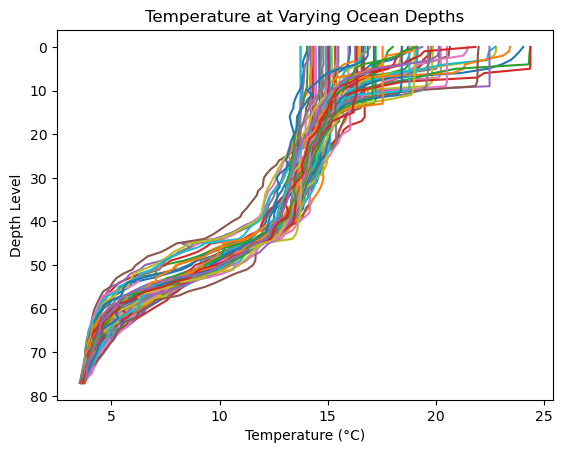

In [94]:
plt.plot(temperature,level);
plt.gca().invert_yaxis()
plt.xlabel("Temperature (°C)")
plt.ylabel("Depth Level")
plt.title("Temperature at Varying Ocean Depths")

Text(0.5, 1.0, 'Salinity at Varying Ocean Depths')

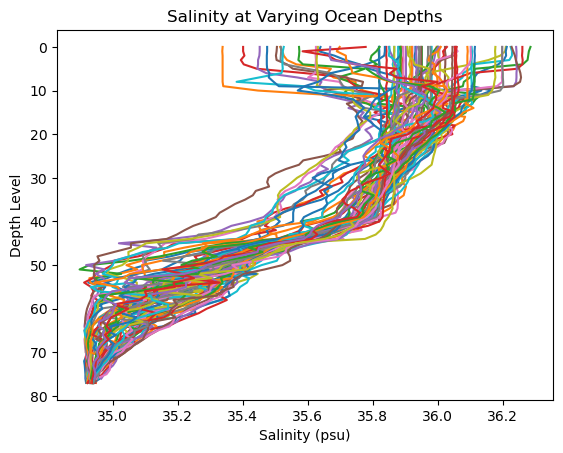

In [95]:
plt.plot(salinity,level);
plt.gca().invert_yaxis()
plt.xlabel("Salinity (psu)")
plt.ylabel("Depth Level")
plt.title("Salinity at Varying Ocean Depths")

Text(0.5, 1.0, 'Pressure at Varying Ocean Depths')

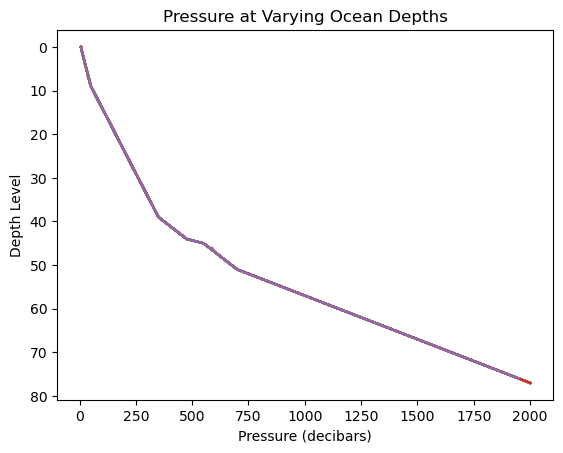

In [99]:
plt.plot(pressure,level);
plt.gca().invert_yaxis()
plt.xlabel("Pressure (decibars)")
plt.ylabel("Depth Level")
plt.title("Pressure at Varying Ocean Depths")

## 2.4 Compute the mean and standard deviation of each of T, S and P at each depth in level.


In [43]:
temperature

array([[18.97400093, 18.43700027, 19.09900093, ..., 19.11300087,
        21.82299995, 20.13100052],
       [18.74099922, 18.39999962, 19.08200073, ..., 18.47200012,
        19.45999908, 20.125     ],
       [18.37000084, 18.37400055, 19.06500053, ..., 18.22999954,
        19.26199913, 20.07699966],
       ...,
       [ 3.79299998,  3.81399989,  3.80200005, ...,  3.80699992,
         3.81100011,  3.8599999 ],
       [ 3.76399994,  3.77800012,  3.75699997, ...,  3.75399995,
         3.74600005,  3.80599999],
       [ 3.74399996,  3.74600005,  3.7249999 , ...,         nan,
         3.71399999,         nan]])

In [44]:
temp_mean = np.mean(temperature,axis=1)
temp_std = np.std(temperature,axis=1)

In [45]:
print("Mean and standard deviation of temperature at each depth in level:")
for i in range(len(level)):
    print("Depth:", level[i], ", Mean:",temp_mean[i], ", Standard Deviation:",temp_std[i])

Mean and standard deviation of temperature at each depth in level:
Depth: 0 , Mean: nan , Standard Deviation: nan
Depth: 1 , Mean: nan , Standard Deviation: nan
Depth: 2 , Mean: nan , Standard Deviation: nan
Depth: 3 , Mean: nan , Standard Deviation: nan
Depth: 4 , Mean: nan , Standard Deviation: nan
Depth: 5 , Mean: nan , Standard Deviation: nan
Depth: 6 , Mean: nan , Standard Deviation: nan
Depth: 7 , Mean: nan , Standard Deviation: nan
Depth: 8 , Mean: nan , Standard Deviation: nan
Depth: 9 , Mean: nan , Standard Deviation: nan
Depth: 10 , Mean: nan , Standard Deviation: nan
Depth: 11 , Mean: nan , Standard Deviation: nan
Depth: 12 , Mean: nan , Standard Deviation: nan
Depth: 13 , Mean: nan , Standard Deviation: nan
Depth: 14 , Mean: nan , Standard Deviation: nan
Depth: 15 , Mean: nan , Standard Deviation: nan
Depth: 16 , Mean: nan , Standard Deviation: nan
Depth: 17 , Mean: nan , Standard Deviation: nan
Depth: 18 , Mean: nan , Standard Deviation: nan
Depth: 19 , Mean: nan , Standar

In [46]:
sal_mean = np.mean(salinity,axis=1)
sal_std = np.std(salinity,axis=1)

In [47]:
print("Mean and standard deviation of salinity at each depth in level:")

for i in range(len(level)):
    print("Depth:", level[i], ", Mean:",sal_mean[i], ", Standard Deviation:",sal_std[i])

Mean and standard deviation of salinity at each depth in level:
Depth: 0 , Mean: nan , Standard Deviation: nan
Depth: 1 , Mean: nan , Standard Deviation: nan
Depth: 2 , Mean: nan , Standard Deviation: nan
Depth: 3 , Mean: nan , Standard Deviation: nan
Depth: 4 , Mean: nan , Standard Deviation: nan
Depth: 5 , Mean: nan , Standard Deviation: nan
Depth: 6 , Mean: nan , Standard Deviation: nan
Depth: 7 , Mean: nan , Standard Deviation: nan
Depth: 8 , Mean: nan , Standard Deviation: nan
Depth: 9 , Mean: nan , Standard Deviation: nan
Depth: 10 , Mean: nan , Standard Deviation: nan
Depth: 11 , Mean: nan , Standard Deviation: nan
Depth: 12 , Mean: nan , Standard Deviation: nan
Depth: 13 , Mean: nan , Standard Deviation: nan
Depth: 14 , Mean: nan , Standard Deviation: nan
Depth: 15 , Mean: nan , Standard Deviation: nan
Depth: 16 , Mean: nan , Standard Deviation: nan
Depth: 17 , Mean: nan , Standard Deviation: nan
Depth: 18 , Mean: nan , Standard Deviation: nan
Depth: 19 , Mean: nan , Standard D

In [48]:
pres_mean = np.mean(pressure,axis=1)
pres_std = np.std(pressure,axis=1)

In [49]:
print("Mean and standard deviation of pressure at each depth in level:")

for i in range(len(level)):
    print("Depth:", level[i], ", Mean:",pres_mean[i], ", Standard Deviation:",pres_std[i])

Mean and standard deviation of pressure at each depth in level:
Depth: 0 , Mean: 6.434666713873545 , Standard Deviation: 0.8534624992402788
Depth: 1 , Mean: nan , Standard Deviation: nan
Depth: 2 , Mean: nan , Standard Deviation: nan
Depth: 3 , Mean: nan , Standard Deviation: nan
Depth: 4 , Mean: nan , Standard Deviation: nan
Depth: 5 , Mean: nan , Standard Deviation: nan
Depth: 6 , Mean: nan , Standard Deviation: nan
Depth: 7 , Mean: nan , Standard Deviation: nan
Depth: 8 , Mean: nan , Standard Deviation: nan
Depth: 9 , Mean: nan , Standard Deviation: nan
Depth: 10 , Mean: nan , Standard Deviation: nan
Depth: 11 , Mean: nan , Standard Deviation: nan
Depth: 12 , Mean: nan , Standard Deviation: nan
Depth: 13 , Mean: nan , Standard Deviation: nan
Depth: 14 , Mean: nan , Standard Deviation: nan
Depth: 15 , Mean: nan , Standard Deviation: nan
Depth: 16 , Mean: nan , Standard Deviation: nan
Depth: 17 , Mean: nan , Standard Deviation: nan
Depth: 18 , Mean: nan , Standard Deviation: nan
Depth

## 2.5 Now make three similar plot, but show only the mean T, S and P at each depth. Show error bars on each plot using the standard deviations.


In [107]:
print(temp_std.shape)
print(sal_std.shape)
print(pres_std.shape)
print(level.shape)

(78,)
(78,)
(78,)
(78,)


Text(0.5, 1.0, 'Mean Temperature at Varying Ocean Depths, with Error Bars')

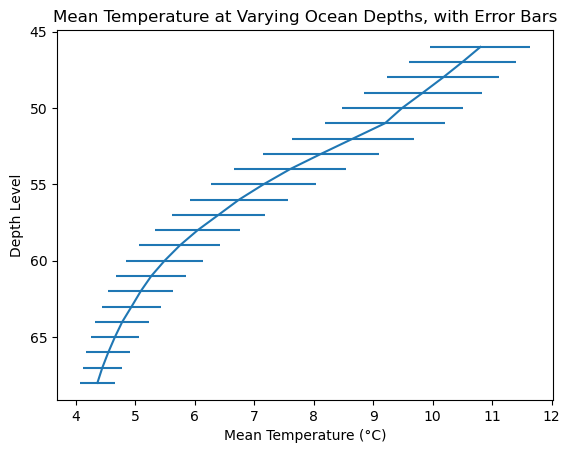

In [101]:
plt.errorbar(temp_mean,level,xerr=temp_std)
plt.gca().invert_yaxis()
plt.xlabel("Mean Temperature (°C)")
plt.ylabel("Depth Level")
plt.title("Mean Temperature at Varying Ocean Depths, with Error Bars")

Text(0.5, 1.0, 'Mean Salinity at Varying Ocean Depths, with Error Bars')

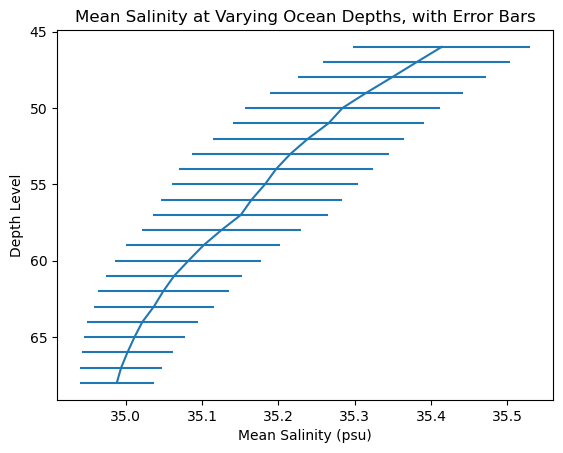

In [102]:
plt.errorbar(sal_mean,level,xerr=sal_std)
plt.gca().invert_yaxis()
plt.xlabel("Mean Salinity (psu)")
plt.ylabel("Depth Level")
plt.title("Mean Salinity at Varying Ocean Depths, with Error Bars")

Text(0.5, 1.0, 'Mean Pressure at Varying Ocean Depths, with Error Bars')

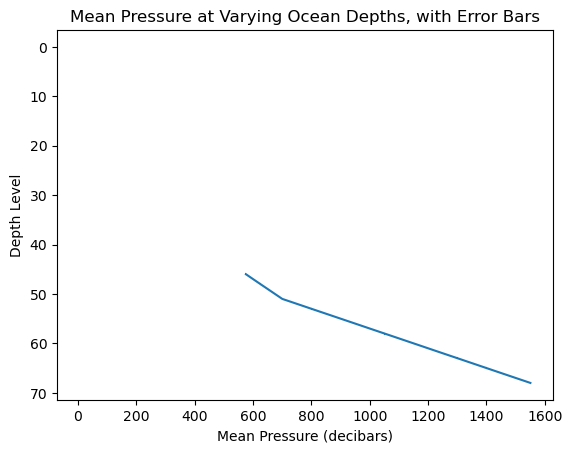

In [103]:
plt.errorbar(pres_mean,level,xerr=pres_std)
plt.gca().invert_yaxis()
plt.xlabel("Mean Pressure (decibars)")
plt.ylabel("Depth Level")
plt.title("Mean Pressure at Varying Ocean Depths, with Error Bars")

## 2.6 Account For Missing Data

The profiles contain many missing values. These are indicated by the special “Not a Number” value, or np.nan.

When you take the mean or standard deviation of data with NaNs in it, the entire result becomes NaN. Instead, if you use the special functions np.nanmean and np.nanstd, you tell NumPy to ignore the NaNs.

Recalculate the means and standard deviations as in the previous sections using these functions and plot the results.

In [70]:
temp_nanmean = np.nanmean(temperature,axis=1)
temp_nanstd = np.nanstd(temperature,axis=1)

In [71]:
print("Mean and standard deviation of temperature at each depth in level:")
for i in range(len(level)):
    print("Depth:", level[i], ", Mean:",temp_nanmean[i], ", Standard Deviation:",temp_nanstd[i])

Mean and standard deviation of temperature at each depth in level:
Depth: 0 , Mean: 17.601726022485185 , Standard Deviation: 2.9250089780535418
Depth: 1 , Mean: 17.572236087587143 , Standard Deviation: 2.8640559124653913
Depth: 2 , Mean: 17.514583296246 , Standard Deviation: 2.833245628372158
Depth: 3 , Mean: 17.423263947168987 , Standard Deviation: 2.751123527650163
Depth: 4 , Mean: 17.249438377275858 , Standard Deviation: 2.6024842197951767
Depth: 5 , Mean: 17.037301337882266 , Standard Deviation: 2.426491647071412
Depth: 6 , Mean: 16.767876611997004 , Standard Deviation: 2.2022058896742647
Depth: 7 , Mean: 16.446095884662785 , Standard Deviation: 1.9975254339474682
Depth: 8 , Mean: 16.17439195272085 , Standard Deviation: 1.7910586224944238
Depth: 9 , Mean: 16.045013556609284 , Standard Deviation: 1.7413279534513904
Depth: 10 , Mean: 15.6582702301644 , Standard Deviation: 1.266084647869944
Depth: 11 , Mean: 15.460729598999023 , Standard Deviation: 1.0785759615786734
Depth: 12 , Mean:

Text(0.5, 1.0, 'Mean Temperature at Varying Ocean Depths (excluding NaN values), with Error Bars')

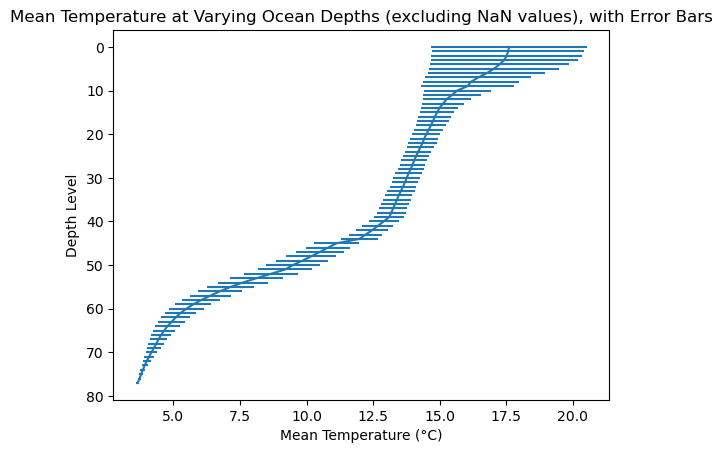

In [104]:
plt.errorbar(temp_nanmean,level,xerr=temp_nanstd)
plt.gca().invert_yaxis()
plt.xlabel("Mean Temperature (°C)")
plt.ylabel("Depth Level")
plt.title("Mean Temperature at Varying Ocean Depths (excluding NaN values), with Error Bars")

In [73]:
sal_nanmean = np.nanmean(salinity,axis=1)
sal_nanstd = np.nanstd(salinity,axis=1)

In [74]:
print("Mean and standard deviation of salinity at each depth in level:")

for i in range(len(level)):
    print("Depth:", level[i], ", Mean:",sal_nanmean[i], ", Standard Deviation:",sal_nanstd[i])

Mean and standard deviation of salinity at each depth in level:
Depth: 0 , Mean: 35.906321799918395 , Standard Deviation: 0.2177505597373686
Depth: 1 , Mean: 35.90223137537638 , Standard Deviation: 0.22181830628640692
Depth: 2 , Mean: 35.9031343460083 , Standard Deviation: 0.21880846568934856
Depth: 3 , Mean: 35.90173138512505 , Standard Deviation: 0.2166159156955439
Depth: 4 , Mean: 35.90544583046273 , Standard Deviation: 0.2084250412175509
Depth: 5 , Mean: 35.91003590413969 , Standard Deviation: 0.194401859863486
Depth: 6 , Mean: 35.90946014613321 , Standard Deviation: 0.18227015035769537
Depth: 7 , Mean: 35.913431455011235 , Standard Deviation: 0.17652957073599815
Depth: 8 , Mean: 35.91967711577544 , Standard Deviation: 0.1699385504409292
Depth: 9 , Mean: 35.926159884478594 , Standard Deviation: 0.16035545399914145
Depth: 10 , Mean: 35.93195456427497 , Standard Deviation: 0.13927144212727055
Depth: 11 , Mean: 35.940553562061204 , Standard Deviation: 0.11711354386117272
Depth: 12 , M

Text(0.5, 1.0, 'Mean Salinity at Varying Ocean Depths (excluding NaN values), with Error Bars')

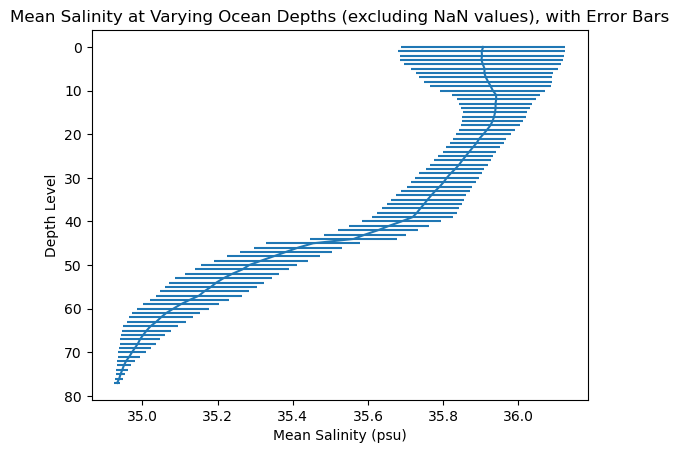

In [105]:
plt.errorbar(sal_nanmean,level,xerr=sal_nanstd)
plt.gca().invert_yaxis()
plt.xlabel("Mean Salinity (psu)")
plt.ylabel("Depth Level")
plt.title("Mean Salinity at Varying Ocean Depths (excluding NaN values), with Error Bars")

In [76]:
pres_nanmean = np.nanmean(pressure,axis=1)
pres_nanstd = np.nanstd(pressure,axis=1)

In [77]:
print("Mean and standard deviation of pressure at each depth in level:")

for i in range(len(level)):
    print("Depth:", level[i], ", Mean:",pres_nanmean[i], ", Standard Deviation:",pres_nanstd[i])

Mean and standard deviation of pressure at each depth in level:
Depth: 0 , Mean: 6.434666713873545 , Standard Deviation: 0.8534624992402788
Depth: 1 , Mean: 10.56891882097399 , Standard Deviation: 0.3734159198894175
Depth: 2 , Mean: 15.54246568026608 , Standard Deviation: 0.38353722610331104
Depth: 3 , Mean: 20.46301360979472 , Standard Deviation: 0.367705657806369
Depth: 4 , Mean: 25.425675521025788 , Standard Deviation: 0.5560626239592544
Depth: 5 , Mean: 30.444594409014726 , Standard Deviation: 0.5075490157490874
Depth: 6 , Mean: 35.443243748432884 , Standard Deviation: 0.4249263566720035
Depth: 7 , Mean: 40.43918939538904 , Standard Deviation: 0.6317751026773168
Depth: 8 , Mean: 45.408108324617956 , Standard Deviation: 0.4848395658804695
Depth: 9 , Mean: 50.378378790778086 , Standard Deviation: 0.6512503931723778
Depth: 10 , Mean: 60.472973230722786 , Standard Deviation: 0.4034641813446031
Depth: 11 , Mean: 70.48378413432353 , Standard Deviation: 0.4673176048944734
Depth: 12 , Mean

Text(0.5, 1.0, 'Mean Pressure at Varying Ocean Depths (excluding NaN values), with Error Bars')

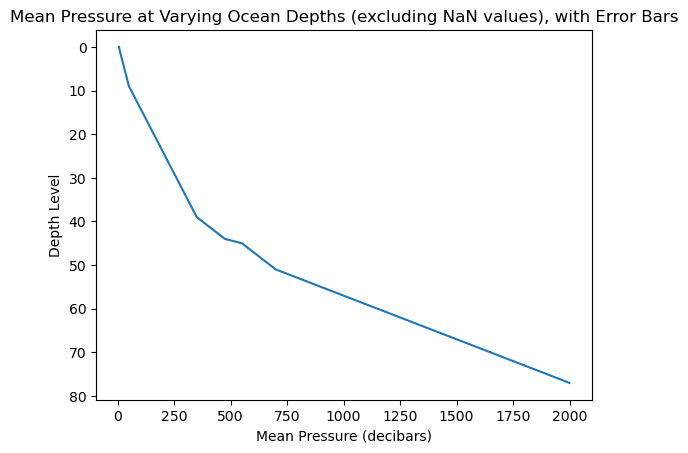

In [106]:
plt.errorbar(pres_nanmean,level,xerr=pres_nanstd)
plt.gca().invert_yaxis()
plt.xlabel("Mean Pressure (decibars)")
plt.ylabel("Depth Level")
plt.title("Mean Pressure at Varying Ocean Depths (excluding NaN values), with Error Bars")

## 2.7 Create a scatter plot of the lon, lat positions of the ARGO float.

Use the plt.scatter function.

Text(0.5, 1.0, 'Longitude and Latitude positions of the ARGO float')

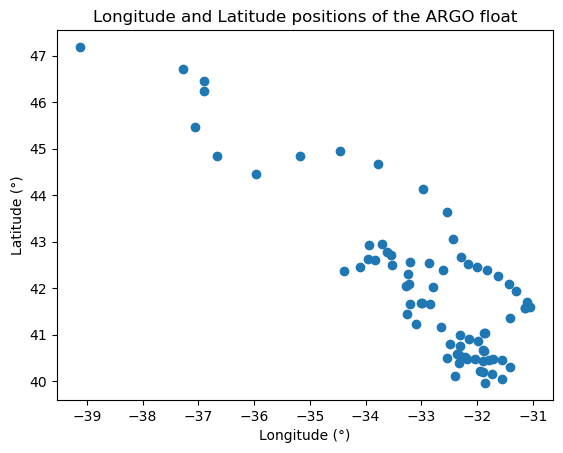

In [79]:
plt.scatter(longitude,latitude)
plt.xlabel("Longitude (°)")
plt.ylabel("Latitude (°)")
plt.title("Longitude and Latitude positions of the ARGO float")